# 1. Prompt engineering 
Prompt engineering is about taking a prompt you've written and improving it to get more reliable, higher-quality outputs. This process involves iterative refinement. 
1. Starting with a basic prompt, 
2. evaluating its performance, then 
3. systematically applying engineering techniques to improve it.

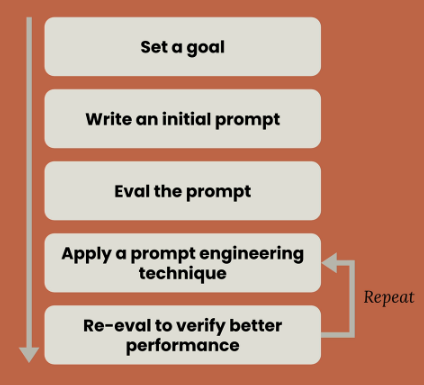

You repeat the last two steps until you're satisfied with the performance. Each iteration should show measurable improvement in your evaluation scores.

## Setting up the Evaluation Pipeline
we'll work with a practical example: creating a prompt that generates one-day meal plans for athletes. The prompt needs to take into account:
1. athlete's height
2. weight
3. goals
4. dietary restrictions
5. then produce a comprehensive meal plan.

The evaluation setup uses:
1. `PromptEvaluator` class that handles dataset generation and model grading.
2. You can control concurrency with the `max_concurrent_tasks` parameter

* *Note: We'll start wtha  low concurrency value of 3 to avoid rate limit errors.*

### Generating Test Data

In [ ]:
dataset = evaluator.generate_dataset(
    task_description="Write a compact, concise 1 day meal plan for a single athlete",
    prompt_inputs_spec={
        "height": "Athlete's height in cm",
        "weight": "Athlete's weight in kg", 
        "goal": "Goal of the athlete",
        "restrictions": "Dietary restrictions of the athlete"
    },
    output_file="dataset.json",
    num_cases=3
)

* *Note: Keep the number of test cases low (2-3) during development to speed up your iteration cycle. You can increase this for final validation.*

### Writing Your Initial Prompt

Start with a simple, naive prompt to establish a baseline.

In [ ]:
def run_prompt(prompt_inputs):
    prompt = f"""
What should this person eat?

- Height: {prompt_inputs["height"]}
- Weight: {prompt_inputs["weight"]}
- Goal: {prompt_inputs["goal"]}
- Dietary restrictions: {prompt_inputs["restrictions"]}
"""
    
    messages = []
    add_user_message(messages, prompt)
    return chat(messages)